# Cloud Coverage — image_taken.jpeg

Runs the trained model on the photo you just took and displays:
- **Image du ciel** (originale)
- **Masque prédit** (blanc = nuage, noir = ciel)

Calcule aussi la couverture nuageuse en %.

In [13]:
import numpy as np
import cv2
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

from predict import predict_mask
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## Configuration

In [14]:
CHECKPOINT = "./checkpoints/best_model.pth"
IMAGE_PATH = "./image_taken.jpeg"
THRESHOLD  = 0.5

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")

Device : cuda


## Chargement du modèle

In [15]:
ckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
cfg  = ckpt["model_config"]

ModelClass = getattr(smp, cfg["architecture"])
model = ModelClass(
    encoder_name    = cfg["encoder_name"],
    encoder_weights = None,
    in_channels     = cfg["in_channels"],
    classes         = cfg["classes"],
).to(DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

IMAGE_SIZE = ckpt.get("image_size", 384)
print(f"Modèle : {cfg['architecture']} ({cfg['encoder_name']})")
print(f"Image size : {IMAGE_SIZE}")
if "iou" in ckpt:
    print(f"Best val IoU : {ckpt['iou']:.4f}   Dice : {ckpt.get('dice', 0):.4f}")

Modèle : Unet (resnet34)
Image size : 384
Best val IoU : 0.8881   Dice : 0.9376


## Inférence

In [16]:
transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

bgr = cv2.imread(IMAGE_PATH)
assert bgr is not None, f"Impossible de lire l'image : {IMAGE_PATH}"

pred_mask, prob_map = predict_mask(model, bgr, transform, DEVICE, THRESHOLD)

coverage = 100.0 * pred_mask.sum() / pred_mask.size
print(f"Couverture nuageuse prédite : {coverage:.1f}%")

Couverture nuageuse prédite : 64.7%


## Visualisation — image / heatmap / masque

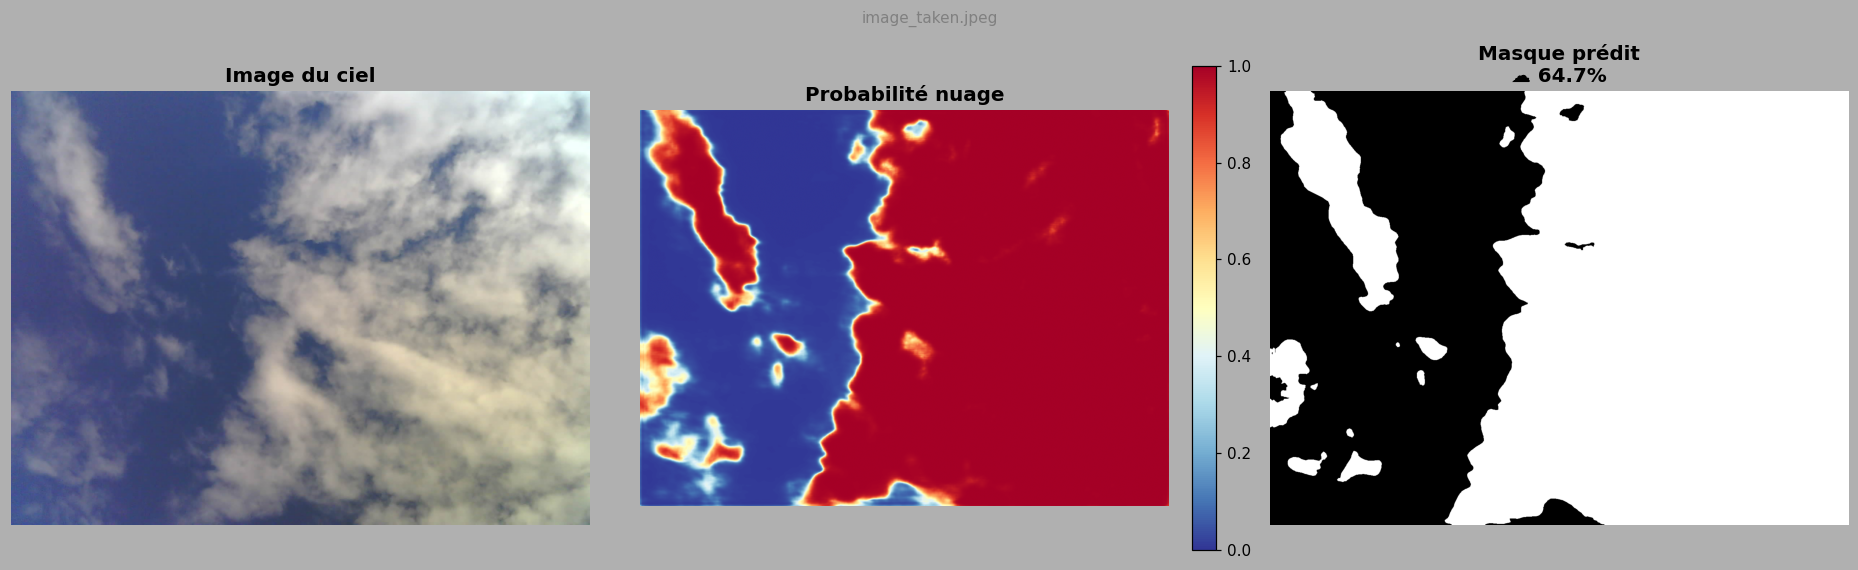

In [17]:
image_rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

pred_vis = np.zeros((*pred_mask.shape, 3), dtype=np.uint8)
pred_vis[pred_mask > 0] = [255, 255, 255]

GREY = "#b0b0b0"

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor(GREY)

for ax in axes:
    ax.set_facecolor(GREY)

axes[0].imshow(image_rgb)
axes[0].set_title("Image du ciel", fontsize=13, fontweight="bold")
axes[0].axis("off")

im = axes[1].imshow(prob_map, cmap="RdYlBu_r", vmin=0, vmax=1)
axes[1].set_title("Probabilité nuage", fontsize=13, fontweight="bold")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(pred_vis)
axes[2].set_title(f"Masque prédit\n☁ {coverage:.1f}%", fontsize=13, fontweight="bold")
axes[2].axis("off")

fig.suptitle("image_taken.jpeg", fontsize=10, color="gray", y=1.01)
plt.tight_layout()
plt.show()

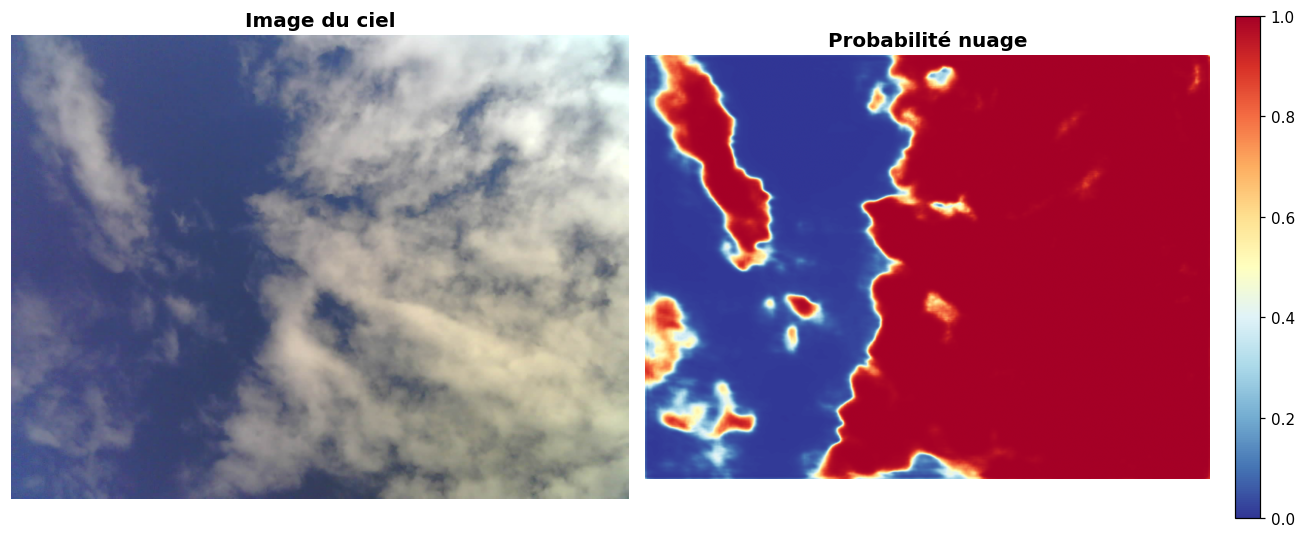

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image_rgb)
axes[0].set_title("Image du ciel", fontsize=13, fontweight="bold")
axes[0].axis("off")

im = axes[1].imshow(prob_map, cmap="RdYlBu_r", vmin=0, vmax=1)
axes[1].set_title("Probabilité nuage", fontsize=13, fontweight="bold")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()